# Radiation figures for COMBLE MIP paper
## Updated as of 6/24/25
* The below notebook computes a number of combined LES-SCM figures for the COMBLE MIP manuscript as well as some modifications for GEWEX Quarterly figures.
* Specific figures include: Figs. S1 & S2; Figs. 8-12
* All requested 1D and 2D variables are here read and plotted. "load_sims" reports variable that are missing. Lines will not show, if a variable is missing or if it contains missing values.
* In case you find inconsistencies in the benchmark set or wish to expand the code, please contact Ann Fridlind (ann.fridlind@nasa.gov), Timothy Juliano (tjuliano@ucar.edu), and Florian Tornow (ft2544@columbia.edu).

## Run functions_plotting.py from the "notebooks/plotting/paper/" directory and then run rest of script from "notebooks/plotting/" to ensure paths work properly.
## Tim's functions_plotting.py script in the "paper/" directory contains modifications

In [1]:
import os

os.chdir("/user-data-home/comble-mip/notebooks/plotting/paper/")


%run functions_plotting.py

os.chdir("/user-data-home/comble-mip/notebooks/plotting/")

## LOAD CERES DATA

In [2]:
ceres_dat = load_ceres(t_filter = 1.)
allsky_dat = load_allsky()

In [3]:
# Group by 'time.rel' and take the mean
ceres_dat_avg = ceres_dat.groupby('time.rel', as_index=False).mean()

/tmp/ipykernel_615/3658865207.py:2: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  ceres_dat_avg = ceres_dat.groupby('time.rel', as_index=False).mean()


## LOAD MODIS and VIIRS DATA

In [4]:
# all data
modis_dat_all    = load_modis(t_filter = 10.)
viirs_dat_all    = load_viirs(t_filter = 10.)

# only 0h time offset data
modis_dat_toff0    = load_modis(t_filter = 0.)
viirs_dat_toff0    = load_viirs(t_filter = 0.)

modis_dat    = load_modis(t_filter = 5.,sza_filter = 75.)
viirs_dat    = load_viirs(t_filter = 5.,sza_filter = 75.)

modis_dat['time.rel'] = np.round(modis_dat['time.rel'])
viirs_dat['time.rel'] = np.round(viirs_dat['time.rel'])

modis_dat_avg = modis_dat.groupby('time.rel', as_index=False).mean()
viirs_dat_avg = viirs_dat.groupby('time.rel', as_index=False).mean()

/tmp/ipykernel_615/200034328.py:15: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  modis_dat_avg = modis_dat.groupby('time.rel', as_index=False).mean()
/tmp/ipykernel_615/200034328.py:16: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  viirs_dat_avg = viirs_dat.groupby('time.rel', as_index=False).mean()


## Plot all CTT data [Fig. S1]

In [39]:
error_1 = np.abs(modis_dat_all['ctt'] - modis_dat_all['ctt.25'])
error_2 = np.abs(modis_dat_all['ctt.75'] - modis_dat_all['ctt'])
error = [error_1,error_2]
plt.errorbar(modis_dat_all.time/3600,modis_dat_all['ctt'],yerr=error,label='MODIS',c='magenta',fmt='s')
#plt.plot(modis_dat.time/3600.,modis_dat['ctt'])

error_1 = np.abs(viirs_dat_all['ctt'] - viirs_dat_all['ctt.25'])
error_2 = np.abs(viirs_dat_all['ctt.75'] - viirs_dat_all['ctt'])
error = [error_1,error_2]
plt.errorbar(viirs_dat_all.time/3600,viirs_dat_all['ctt'],yerr=error,label='VIIRS',c='k',fmt='o')

plt.xlim(-2.5,18.5)
plt.xlabel('Time [h]')
plt.ylabel('CTT [deg C]')
plt.title('All Data')
plt.legend(loc='upper left')
plt.grid()

plt.savefig('./paper/all_modis_viirs_ctt.png',dpi=300)
plt.close()

## Plot time offset 0 h CTT data [Fig. S2]

In [40]:
error_1 = np.abs(modis_dat_toff0['ctt'] - modis_dat_toff0['ctt.25'])
error_2 = np.abs(modis_dat_toff0['ctt.75'] - modis_dat_toff0['ctt'])
error = [error_1,error_2]
plt.errorbar(modis_dat_toff0.time/3600,modis_dat_toff0['ctt'],yerr=error,label='MODIS',c='magenta',fmt='s')
#plt.plot(modis_dat.time/3600.,modis_dat['ctt'])

error_1 = np.abs(viirs_dat_toff0['ctt'] - viirs_dat_toff0['ctt.25'])
error_2 = np.abs(viirs_dat_toff0['ctt.75'] - viirs_dat_toff0['ctt'])
error = [error_1,error_2]
plt.errorbar(viirs_dat_toff0.time/3600,viirs_dat_toff0['ctt'],yerr=error,label='VIIRS',c='k',fmt='o')

plt.xlim(-2.5,18.5)
plt.xlabel('Time [h]')
plt.ylabel('CTT [deg C]')
plt.title('Time offset = 0 h')
plt.legend(loc='upper left')
plt.grid()

plt.savefig('./paper/0h_modis_viirs_ctt.png',dpi=300)
plt.close()

## Load "No Ice" LES sims

In [5]:
keyword_all = 'FixN_noice.' 
sim_keyword_dharma = 'dharma/sandbox/DHARMA_Lx25_dx100_'+keyword_all
sim_keyword_icon = 'icon/staged/ICON_Lx25_dx100_'+keyword_all
sim_keyword_sam = 'sam-pnnl/sandbox/SAM_Lx25_dx100_'+keyword_all
sim_keyword_ucla = 'uclales-salsa/sandbox/UCLALES-SALSA_Lx25_dx100_'+keyword_all
sim_keyword_wrf = 'wrf/sandbox/WRF_Lx25_dx100_'+keyword_all
sim_keyword_msu = 'msu-rcc-les/sandbox/MSU_RCC_LES_SM_Lx25_dx100_'+keyword_all
sim_keyword_mimica = 'mimica/sandbox/MIMICA_Lx25_dx100_'+keyword_all
sim_keyword_cm1 = 'cm1-p3/sandbox/CM1-P3_Lx25_dx100_'+keyword_all
sim_keyword_dales = 'DALES/sandbox/DALES_Lx25_dx100_'+keyword_all
sim_keyword_scale = 'scale-sdm/sandbox/scale-sn14_Lx25_dx100_'+keyword_all

In [6]:
#vars_mean_list = pd.read_excel('https://docs.google.com/spreadsheets/d/1Vl8jYGviet7EtXZuQiitrx4NSkV1x27aJAhxxjBb9zI/export?gid=0&format=xlsx',
#                              sheet_name='Mean')

vars_mean_list = pd.read_excel('../../data_files/COMBLE_CAO_LES-SCM_Intercomparison_Output_Variables.xlsx')

## short names
var_vec_1d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time'])
var_vec_2d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time, height'])

## long names
var_vec_1d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time'])
var_vec_2d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time, height'])

## Units
var_vec_1d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time'])
var_vec_2d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time, height'])

#var_vec_1d = ['hfss','hfls','ts','lwpr','lwpc','iwp','od','cfc','rlut','rlds','clt']
#var_vec_2d = ['theta','qv','qlc','qlr','qic','ta','ua','va','hur','huri','prf']

In [7]:
df_col_1d_dales_noice,df_col_2d_dales_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dales,diag_zi_ctt=True)
df_col_1d_cm1_noice,df_col_2d_cm1_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_cm1,diag_zi_ctt=True)
df_col_1d_mimica_noice,df_col_2d_mimica_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_mimica,diag_zi_ctt=True)
df_col_1d_msu_noice,df_col_2d_msu_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_msu,diag_zi_ctt=True)
df_col_1d_dharma_noice,df_col_2d_dharma_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dharma,diag_zi_ctt=True)
df_col_1d_icon_noice,df_col_2d_icon_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_icon,diag_zi_ctt=True)
df_col_1d_sam_noice,df_col_2d_sam_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_sam,diag_zi_ctt=True)
df_col_1d_ucla_noice,df_col_2d_ucla_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_ucla,diag_zi_ctt=True)
df_col_1d_wrf_noice,df_col_2d_wrf_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_wrf,diag_zi_ctt=True)
df_col_1d_scale_noice,df_col_2d_scale_noice = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_scale,diag_zi_ctt=True)

Loading variables: f(time)
../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
lwpr not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
iwp not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
pri not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
ssaf not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
Loading variables: f(time,height)
../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
huri not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
qlr not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
qic not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
qis not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
qig not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
nlc not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc
nlr not found in ../..

## Load "FixN" LES sims

In [8]:
keyword_all = 'FixN.' 
sim_keyword_dharma = 'dharma/sandbox/DHARMA_Lx25_dx100_'+keyword_all
sim_keyword_icon = 'icon/staged/ICON_Lx25_dx100_'+keyword_all
sim_keyword_sam = 'sam-pnnl/sandbox/SAM_Lx25_dx100_'+keyword_all
sim_keyword_ucla = 'uclales-salsa/sandbox/UCLALES-SALSA_Lx25_dx100_'+keyword_all
sim_keyword_wrf = 'wrf/sandbox/WRF_Lx25_dx100_'+keyword_all
sim_keyword_msu = 'msu-rcc-les/sandbox/MSU_RCC_LES_SM_Lx25_dx100_'+keyword_all
sim_keyword_mimica = 'mimica/sandbox/MIMICA_Lx25_dx100_FixN.nc'
sim_keyword_cm1 = 'cm1-p3/sandbox/CM1-P3_Lx25_dx100_FixN.nc'
sim_keyword_dales = 'DALES/sandbox/DALES_Lx25_dx100_FixN.nc'
sim_keyword_scales = 'scale-sdm/sandbox/scale-sn14_Lx25_dx100_FixN.nc'

In [9]:
#vars_mean_list = pd.read_excel('https://docs.google.com/spreadsheets/d/1Vl8jYGviet7EtXZuQiitrx4NSkV1x27aJAhxxjBb9zI/export?gid=0&format=xlsx',
#                              sheet_name='Mean')
vars_mean_list = pd.read_excel('../../data_files/COMBLE_CAO_LES-SCM_Intercomparison_Output_Variables.xlsx')


## short names
var_vec_1d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time'])
var_vec_2d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time, height'])

## long names
var_vec_1d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time'])
var_vec_2d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time, height'])

## Units
var_vec_1d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time'])
var_vec_2d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time, height'])

#var_vec_1d = ['hfss','hfls','ts','lwpr','lwpc','iwp','od','cfc','rlut','rlds','clt']
#var_vec_2d = ['theta','qv','qlc','qlr','qic','ta','ua','va','hur','huri','prf']

In [10]:
df_col_1d_dales,df_col_2d_dales = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dales,diag_zi_ctt=True)
df_col_1d_cm1,df_col_2d_cm1 = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_cm1,diag_zi_ctt=True)
df_col_1d_mimica,df_col_2d_mimica = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_mimica,diag_zi_ctt=True)
df_col_1d_msu,df_col_2d_msu = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_msu,diag_zi_ctt=True)
df_col_1d_dharma,df_col_2d_dharma = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dharma,diag_zi_ctt=True)
df_col_1d_icon,df_col_2d_icon = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_icon,diag_zi_ctt=True)
df_col_1d_sam,df_col_2d_sam = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_sam,diag_zi_ctt=True)
df_col_1d_ucla,df_col_2d_ucla = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_ucla,diag_zi_ctt=True)
df_col_1d_wrf,df_col_2d_wrf = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_wrf,diag_zi_ctt=True)
df_col_1d_scales,df_col_2d_scales = load_sims('../../output_les/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_scales,diag_zi_ctt=True)

Loading variables: f(time)
../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
ssaf not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
Loading variables: f(time,height)
../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
na1 not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
na2 not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
na3 not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
eps not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
w2 shows NAN values in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
wth not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
vf_thli not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
wqv not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
vf_qt not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
flc not found in ../../output_les/DALES/sandbox/DALES_Lx25_dx100_FixN.nc
prf not fou

## Load "No Ice" SCM sims

In [11]:
#vars_mean_list = pd.read_excel('https://docs.google.com/spreadsheets/d/1Vl8jYGviet7EtXZuQiitrx4NSkV1x27aJAhxxjBb9zI/export?gid=1026157027&format=xlsx',
#                              sheet_name='SCM')

## short names
#var_vec_1d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time'])
#var_vec_2d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time, layer'])

#var_vec_2d = var_vec_2d[var_vec_2d!='zf']

## long names
#var_vec_1d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time'])

## Units
#var_vec_1d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time'])
#var_vec_2d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time, layer'])

var_vec_1d = ['hfss','hfls','ts','lwpr','lwpc','iwp','od','cfc','rlut','rlds','cf','pr']
var_vec_2d = ['theta','qv','qlc','qlr','qi','ta','ua','va','hur','huri','prf','tke','pa','wth','zf']

In [12]:
## select SCM run(s) of interest
#sim_keyword_ccpp_noice = 'CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_noice_def_z0.nc'
sim_keyword_modelE3_phys_noice = 'modelE/sandbox/ModelE3-Phys_FixN_noice_def_z0.nc'
sim_keyword_icon_scm_noice = 'icon-scm/sandbox/ICON-SCM_FixN_noice.nc'
#sim_keyword_aoscm1 = 'AOSCM/sandbox/AOSCM_FixN_def_z0_alt.nc'
sim_keyword_dales_edmf_noice = 'DALES-EDMFn/sandbox/DALES-EDMFn_FixN_noice.nc'
sim_keyword_e3sm1_noice = 'E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc'
#sim_keyword_slav = 'SLAV_SCM/sandbox/SLAV1D_Phys_ice_alt_ref.nc'
sim_keyword_lmdz_noice = 'LMDZ/staged/LMDZ_FixN_noice.nc'

## example using SCM
#df_col_1d_ccpp,df_col_2d_ccpp = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_ccpp_noice,diag_zi_ctt=True)
#df_col_1d_slav,df_col_2d_slav = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_slav,diag_zi_ctt=True,QTHRES=4.0e-5)
df_col_1d_e3sm1_noice,df_col_2d_e3sm1_noice = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_e3sm1_noice,diag_zi_ctt=True)
df_col_1d_dales_edmf_noice,df_col_2d_dales_edmf_noice = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dales_edmf_noice,diag_zi_ctt=True)
#df_col_1d_aoscm1,df_col_2d_aoscm1 = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_aoscm1,diag_zi_ctt=True)
df_col_1d_modelE3_phys_noice,df_col_2d_modelE3_phys_noice = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_modelE3_phys_noice,diag_zi_ctt=True)
df_col_1d_icon_scm_noice,df_col_2d_icon_scm_noice = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_icon_scm_noice,diag_zi_ctt=True)
df_col_1d_lmdz_noice,df_col_2d_lmdz_noice = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_lmdz_noice,diag_zi_ctt=True,QTHRES=4.0e-5)


Loading variables: f(time)
../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
iwp shows NAN values in ../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
od shows NAN values in ../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
Loading variables: f(time,height)
../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
qi shows NAN values in ../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
prf shows NAN values in ../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
wth shows NAN values in ../../output_scm/E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
computing inversion height, cloud-top height, and cloud-top temperature
E3SM/sandbox/E3SMv2-Phys_FixN_noice_def_z0_alt_no_ugvg.nc
Loading variables: f(time)
../../output_scm/DALES-EDMFn/sandbox/DALES-EDMFn_FixN_noice.nc
od shows NAN values in ../../output_scm/DALES-EDMFn/sandbox/DALES-EDMFn_FixN

## Load "FixN" SCM sims

In [13]:
#vars_mean_list = pd.read_excel('https://docs.google.com/spreadsheets/d/1Vl8jYGviet7EtXZuQiitrx4NSkV1x27aJAhxxjBb9zI/export?gid=1026157027&format=xlsx',
#                              sheet_name='SCM')

## short names
#var_vec_1d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time'])
#var_vec_2d = np.asarray(vars_mean_list.variable_id[vars_mean_list.dimensions == 'time, layer'])

#var_vec_2d = var_vec_2d[var_vec_2d!='zf']

## long names
#var_vec_1d_long = np.asarray(vars_mean_list.standard_name[vars_mean_list.dimensions == 'time'])

## Units
#var_vec_1d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time'])
#var_vec_2d_units = np.asarray(vars_mean_list.units[vars_mean_list.dimensions == 'time, layer'])

var_vec_1d = ['hfss','hfls','ts','lwpr','lwpc','iwp','od','cfc','rlut','rlds','cf','pr']
var_vec_2d = ['theta','qv','qlc','qlr','qi','ta','ua','va','hur','huri','prf','tke','pa','wth']

In [14]:
## select SCM run(s) of interest
sim_keyword_ccpp = 'CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc'
sim_keyword_modelE3_phys = 'modelE/sandbox/ModelE3-Phys_FixN_def_z0.nc'
sim_keyword_icon_scm = 'icon-scm/sandbox/ICON-SCM_FixN.nc'
sim_keyword_aoscm1 = 'AOSCM/sandbox/AOSCM_FixN_def_z0_alt.nc'
sim_keyword_dales_edmf = 'DALES-EDMFn/sandbox/DALES-EDMFn_FixN.nc'
sim_keyword_e3sm1 = 'E3SM/sandbox/E3SMv2-Phys_FixN_def_z0_alt_no_ugvg.nc'
sim_keyword_slav = 'SLAV_SCM/sandbox/SLAV1D_Phys_ice_alt_ref.nc'
sim_keyword_lmdz = 'LMDZ/staged_2/LMDZ_FixN.nc'

## example using SCM
df_col_1d_ccpp,df_col_2d_ccpp = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_ccpp,diag_zi_ctt=True,QTHRES=4.0e-5)
df_col_1d_slav,df_col_2d_slav = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_slav,diag_zi_ctt=True,QTHRES=4.0e-5)
df_col_1d_e3sm1,df_col_2d_e3sm1 = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_e3sm1,diag_zi_ctt=True)
df_col_1d_dales_edmf,df_col_2d_dales_edmf = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_dales_edmf,diag_zi_ctt=True)
df_col_1d_aoscm1,df_col_2d_aoscm1 = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_aoscm1,diag_zi_ctt=True)
df_col_1d_modelE3_phys,df_col_2d_modelE3_phys = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_modelE3_phys,diag_zi_ctt=True)
df_col_1d_icon_scm,df_col_2d_icon_scm = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_icon_scm,diag_zi_ctt=True,QTHRES=2.0e-6)
df_col_1d_lmdz,df_col_2d_lmdz = load_sims('../../output_scm/',var_vec_1d,var_vec_2d,t_shift=-2,keyword=sim_keyword_lmdz,diag_zi_ctt=True,QTHRES=4.0e-5)


Loading variables: f(time)
../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
lwpr shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
lwpc shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
iwp shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
od shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
cfc shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
rlut shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
cf shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
pr shows NAN values in ../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
Loading variables: f(time,height)
../../output_scm/CCPP-SCM/sandbox/CCPP-SCM-GFSv16_dx13000_FixN_def_z0.nc
prf shows NAN val

## Plot cloud top height scales with surface energy input [Fig. 8]

120

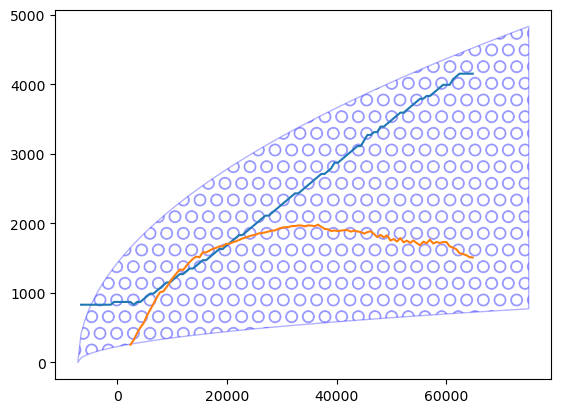

In [51]:
## prepare theoretical envelope for plot

min_ratio = np.nanmin(2/df_col_1d_dharma_noice['dthdz_zi']) * (np.nanmin(df_col_1d_dharma_noice['wth_surf']) - np.nanmax(df_col_1d_dharma_noice['wth_zi']))
max_ratio = np.nanmax(2/df_col_1d_dharma_noice['dthdz_zi']) * (np.nanmax(df_col_1d_dharma_noice['wth_surf']) - np.nanmin(df_col_1d_dharma_noice['wth_zi']))

tt = np.arange(23*6)*600.
plt.fill_between(tt-7200, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch="O",edgecolor='b')

plt.plot(df_col_1d_dharma_noice['time'],df_col_1d_dharma_noice['zi'])
plt.plot(df_col_1d_dharma_noice['time'],np.sqrt(df_col_1d_dharma_noice['time']*2*(df_col_1d_dharma_noice['wth_surf'] - df_col_1d_dharma_noice['wth_zi'])/df_col_1d_dharma_noice['dthdz_zi']))
#plt.plot(tt-7200, np.sqrt(min_ratio * tt))
#plt.plot(tt-7200, np.sqrt(max_ratio * tt))

hf_ave = np.mean(df_col_1d_dharma_noice['hfls']) + np.mean(df_col_1d_dharma_noice['hfss'])
#df_col_1d_dharma_noice['hf_ave']

#plt.fill_between(df_col_1d_dharma_noice['hf_ave'].cumsum(), np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch="O",edgecolor='b')
len(tt)
len(df_col_1d_dharma_noice)

In [215]:
## address reviewer concern: check out precip rate at cloud-base - surface

## LES NO ICE
cc = 'k'
#plt.fill_between((hf_ave*(tt*0 + 1)).cumsum()*600, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch=".",edgecolor='grey')
plt.plot(df_col_1d_dharma_noice['time']/3600.,np.abs(df_col_1d_dharma_noice['pr_cb']-df_col_1d_dharma_noice['pr']),c=cc)
plt.plot(df_col_1d_icon_noice['time']/3600.,np.abs(df_col_1d_icon_noice['pr_cb']-df_col_1d_icon_noice['pr']),c=cc)
plt.plot(df_col_1d_ucla_noice['time']/3600.,np.abs(df_col_1d_ucla_noice['pr_cb']-df_col_1d_ucla_noice['pr']),c=cc)
plt.plot(df_col_1d_wrf_noice['time']/3600.,np.abs(df_col_1d_wrf_noice['pr_cb']-df_col_1d_wrf_noice['pr']),c=cc)
plt.plot(df_col_1d_msu_noice['time']/3600.,np.abs(df_col_1d_msu_noice['pr_cb']-df_col_1d_msu_noice['pr']),c=cc)
plt.plot(df_col_1d_mimica_noice['time']/3600.,np.abs(df_col_1d_mimica_noice['pr_cb']-df_col_1d_mimica_noice['pr']),c=cc)
plt.plot(df_col_1d_dales_noice['time']/3600.,np.abs(df_col_1d_dales_noice['pr_cb']-df_col_1d_dales_noice['pr']),c=cc)
plt.plot(df_col_1d_cm1_noice['time']/3600.,np.abs(df_col_1d_cm1_noice['pr_cb']-df_col_1d_cm1_noice['pr']),c=cc)
plt.plot(df_col_1d_scale_noice['time']/3600.,np.abs(df_col_1d_scale_noice['pr_cb']-df_col_1d_scale_noice['pr']),c=cc,label='LES Liquid-Only')


## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['time']/3600.,np.abs(df_col_1d_dharma['pr_cb']-df_col_1d_dharma['pr']),c=cc)
plt.plot(df_col_1d_icon['time']/3600.,np.abs(df_col_1d_icon['pr_cb']-df_col_1d_icon['pr']),c=cc)
plt.plot(df_col_1d_ucla['time']/3600.,np.abs(df_col_1d_ucla['pr_cb']-df_col_1d_ucla['pr']),c=cc)
plt.plot(df_col_1d_wrf['time']/3600.,np.abs(df_col_1d_wrf['pr_cb']-df_col_1d_wrf['pr']),c=cc)
plt.plot(df_col_1d_msu['time']/3600.,np.abs(df_col_1d_msu['pr_cb']-df_col_1d_msu['pr']),c=cc)
plt.plot(df_col_1d_mimica['time']/3600.,np.abs(df_col_1d_mimica['pr_cb']-df_col_1d_mimica['pr']),c=cc)
plt.plot(df_col_1d_dales['time']/3600.,np.abs(df_col_1d_dales['pr_cb']-df_col_1d_dales['pr']),c=cc)
plt.plot(df_col_1d_cm1['time']/3600.,np.abs(df_col_1d_cm1['pr_cb']-df_col_1d_cm1['pr']),c=cc)
plt.plot(df_col_1d_scales['time']/3600.,np.abs(df_col_1d_scales['pr_cb']-df_col_1d_scales['pr']),c=cc,label='LES Mixed-Phase')

## SCM
lw = 2.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.plot(df_col_1d_dales_edmf['time']/3600.,np.abs(df_col_1d_dales_edmf['pr_cb']-df_col_1d_dales_edmf['pr']),c=cc[0],lw=lw,label='DALES-EDMFn')
plt.plot(df_col_1d_modelE3_phys['time']/3600.,np.abs(df_col_1d_modelE3_phys['pr_cb']-df_col_1d_modelE3_phys['pr']),c=cc[1],lw=lw,label='ModelE3')
plt.plot(df_col_1d_icon_scm['time']/3600.,np.abs(df_col_1d_icon_scm['pr_cb']-df_col_1d_icon_scm['pr']),c=cc[2],lw=lw,label='ICON-SCM')
plt.plot(df_col_1d_aoscm1['time']/3600.,np.abs(df_col_1d_aoscm1['pr_cb']-df_col_1d_aoscm1['pr']),c=cc[3],lw=lw,label='AOSCM')
plt.plot(df_col_1d_e3sm1['time']/3600.,np.abs(df_col_1d_e3sm1['pr_cb']-df_col_1d_e3sm1['pr']),c=cc[4],lw=lw,label='E3SM') 
plt.plot(df_col_1d_slav['time']/3600.,np.abs(df_col_1d_slav['pr_cb']-df_col_1d_slav['pr']),c=cc[5],lw=lw,label='SLAV') 
plt.plot(df_col_1d_ccpp['time']/3600.,np.abs(df_col_1d_ccpp['pr_cb']-df_col_1d_ccpp['pr']),c=cc[6],lw=lw,label='CCPP')
plt.plot(df_col_1d_lmdz['time']/3600.,np.abs(df_col_1d_lmdz['pr_cb']-df_col_1d_lmdz['pr']),c=cc[7],lw=lw,label='LMDZ')
plt.xlabel('Time (h)',fontsize=18)
plt.ylabel('Cloud-Top Height [m]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend(loc='upper left')
plt.grid()
plt.savefig('./paper/time_pr_subcloud_R1.png',dpi=600,bbox_inches='tight')
plt.close()
#plt.show()

In [214]:
## address reviewer concern: check out precip rate at cloud-base - surface

## LES NO ICE
cc = 'k'
#plt.fill_between((hf_ave*(tt*0 + 1)).cumsum()*600, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch=".",edgecolor='grey')
plt.plot(df_col_1d_dharma_noice['time']/3600.,df_col_1d_dharma_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_icon_noice['time']/3600.,df_col_1d_icon_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_ucla_noice['time']/3600.,df_col_1d_ucla_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_wrf_noice['time']/3600.,df_col_1d_wrf_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_msu_noice['time']/3600.,df_col_1d_msu_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_mimica_noice['time']/3600.,df_col_1d_mimica_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_dales_noice['time']/3600.,df_col_1d_dales_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_cm1_noice['time']/3600.,df_col_1d_cm1_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_scale_noice['time']/3600.,df_col_1d_scale_noice['delta_qt'],c=cc,label='LES Liquid-Only')


## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['time']/3600.,df_col_1d_dharma['delta_qt'],c=cc)
plt.plot(df_col_1d_icon['time']/3600.,df_col_1d_icon['delta_qt'],c=cc)
plt.plot(df_col_1d_ucla['time']/3600.,df_col_1d_ucla['delta_qt'],c=cc)
plt.plot(df_col_1d_wrf['time']/3600.,df_col_1d_wrf['delta_qt'],c=cc)
plt.plot(df_col_1d_msu['time']/3600.,df_col_1d_msu['delta_qt'],c=cc)
plt.plot(df_col_1d_mimica['time']/3600.,df_col_1d_mimica['delta_qt'],c=cc)
plt.plot(df_col_1d_dales['time']/3600.,df_col_1d_dales['delta_qt'],c=cc)
plt.plot(df_col_1d_cm1['time']/3600.,df_col_1d_cm1['delta_qt'],c=cc)
plt.plot(df_col_1d_scales['time']/3600.,df_col_1d_scales['delta_qt'],c=cc,label='LES Mixed-Phase')

## SCM
lw = 2.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.plot(df_col_1d_dales_edmf['time']/3600.,df_col_1d_dales_edmf['delta_qt'],c=cc[0],lw=lw,label='DALES-EDMFn')
plt.plot(df_col_1d_modelE3_phys['time']/3600.,df_col_1d_modelE3_phys['delta_qt'],c=cc[1],lw=lw,label='ModelE3')
plt.plot(df_col_1d_icon_scm['time']/3600.,df_col_1d_icon_scm['delta_qt'],c=cc[2],lw=lw,label='ICON-SCM')
plt.plot(df_col_1d_aoscm1['time']/3600.,df_col_1d_aoscm1['delta_qt'],c=cc[3],lw=lw,label='AOSCM')
plt.plot(df_col_1d_e3sm1['time']/3600.,df_col_1d_e3sm1['delta_qt'],c=cc[4],lw=lw,label='E3SM') 
plt.plot(df_col_1d_slav['time']/3600.,df_col_1d_slav['delta_qt'],c=cc[5],lw=lw,label='SLAV') 
plt.plot(df_col_1d_ccpp['time']/3600.,df_col_1d_ccpp['delta_qt'],c=cc[6],lw=lw,label='CCPP')
plt.plot(df_col_1d_lmdz['time']/3600.,df_col_1d_lmdz['delta_qt'],c=cc[7],lw=lw,label='LMDZ')
plt.xlabel('Time (h)',fontsize=18)
plt.ylabel('Cloud-Top Height [m]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend(loc='upper left')
plt.grid()
plt.savefig('./paper/time_delta_qt_R1.png',dpi=600,bbox_inches='tight')
plt.close()
#plt.show()

In [61]:
## LES NO ICE
cc = 'k'
plt.fill_between((hf_ave*(tt*0 + 1)).cumsum()*600, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch=".",edgecolor='grey')
plt.plot(df_col_1d_dharma_noice['hfls'].cumsum()*600 + df_col_1d_dharma_noice['hfss'].cumsum()*600,df_col_1d_dharma_noice['cth'],c=cc)
plt.plot(df_col_1d_icon_noice['hfls'].cumsum()*600 + df_col_1d_icon_noice['hfss'].cumsum()*600,df_col_1d_icon_noice['cth'],c=cc)
plt.plot(df_col_1d_sam_noice['hfls'].cumsum()*600 + df_col_1d_sam_noice['hfss'].cumsum()*600,df_col_1d_sam_noice['cth'],c=cc)
plt.plot(df_col_1d_ucla_noice['hfls'].cumsum()*600 + df_col_1d_ucla_noice['hfss'].cumsum()*600,df_col_1d_ucla_noice['cth'],c=cc)
plt.plot(df_col_1d_wrf_noice['hfls'].cumsum()*600 + df_col_1d_wrf_noice['hfss'].cumsum()*600,df_col_1d_wrf_noice['cth'],c=cc)
plt.plot(df_col_1d_msu_noice['hfls'].cumsum()*600 + df_col_1d_msu_noice['hfss'].cumsum()*600,df_col_1d_msu_noice['cth'],c=cc)
plt.plot(df_col_1d_mimica_noice['hfls'].cumsum()*600 + df_col_1d_mimica_noice['hfss'].cumsum()*600,df_col_1d_mimica_noice['cth'],c=cc)
plt.plot(df_col_1d_dales_noice['hfls'].cumsum()*600 + df_col_1d_dales_noice['hfss'].cumsum()*600,df_col_1d_dales_noice['cth'],c=cc)
plt.plot(df_col_1d_cm1_noice['hfls'].cumsum()*600 + df_col_1d_cm1_noice['hfss'].cumsum()*600,df_col_1d_cm1_noice['cth'],c=cc)
plt.plot(df_col_1d_scale_noice['hfls'].cumsum()*600 + df_col_1d_scale_noice['hfss'].cumsum()*600,df_col_1d_scale_noice['cth'],c=cc,label='LES Liquid Only')

## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['hfls'].cumsum()*600 + df_col_1d_dharma['hfss'].cumsum()*600,df_col_1d_dharma['cth'],c=cc)
plt.plot(df_col_1d_icon['hfls'].cumsum()*600 + df_col_1d_icon['hfss'].cumsum()*600,df_col_1d_icon['cth'],c=cc)
plt.plot(df_col_1d_sam['hfls'].cumsum()*600 + df_col_1d_sam['hfss'].cumsum()*600,df_col_1d_sam['cth'],c=cc)
plt.plot(df_col_1d_ucla['hfls'].cumsum()*600 + df_col_1d_ucla['hfss'].cumsum()*600,df_col_1d_ucla['cth'],c=cc)
plt.plot(df_col_1d_wrf['hfls'].cumsum()*600 + df_col_1d_wrf['hfss'].cumsum()*600,df_col_1d_wrf['cth'],c=cc)
plt.plot(df_col_1d_msu['hfls'].cumsum()*600 + df_col_1d_msu['hfss'].cumsum()*600,df_col_1d_msu['cth'],c=cc)
plt.plot(df_col_1d_mimica['hfls'].cumsum()*600 + df_col_1d_mimica['hfss'].cumsum()*600,df_col_1d_mimica['cth'],c=cc)
plt.plot(df_col_1d_cm1['hfls'].cumsum()*600 + df_col_1d_cm1['hfss'].cumsum()*600,df_col_1d_cm1['cth'],c=cc)
plt.plot(df_col_1d_dales['hfls'].cumsum()*600 + df_col_1d_dales['hfss'].cumsum()*600,df_col_1d_dales['cth'],c=cc)
plt.plot(df_col_1d_scales['hfls'].cumsum()*600 + df_col_1d_scales['hfss'].cumsum()*600,df_col_1d_scales['cth'],c=cc,label='LES Mixed-Phase')


## SCM
lw = 2.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.plot(df_col_1d_dales_edmf['hfls'].cumsum()*600 + df_col_1d_dales_edmf['hfss'].cumsum()*600,df_col_1d_dales_edmf['cth'],c=cc[0],lw=lw,label='DALES-EDMFn')
plt.plot(df_col_1d_modelE3_phys['hfls'].cumsum()*600*3. + df_col_1d_modelE3_phys['hfss'].cumsum()*600*3.,df_col_1d_modelE3_phys['cth'],c=cc[1],lw=lw,label='ModelE3') # reporting every 30 min instead of 10 min
plt.plot(df_col_1d_icon_scm['hfls'].cumsum()*600 + df_col_1d_icon_scm['hfss'].cumsum()*600,df_col_1d_icon_scm['cth'],c=cc[2],lw=lw,label='ICON-SCM')
plt.plot(df_col_1d_aoscm1['hfls'].cumsum()*450 + df_col_1d_aoscm1['hfss'].cumsum()*450,df_col_1d_aoscm1['cth'],c=cc[3],lw=lw,label='AOSCM')
plt.plot(df_col_1d_e3sm1['hfls'].cumsum()*600*3. + df_col_1d_e3sm1['hfss'].cumsum()*600*3.,df_col_1d_e3sm1['cth'],c=cc[4],lw=lw,label='E3SM') # reporting every 30 min instead of 10 min
plt.plot(df_col_1d_slav['hfls'].cumsum()*600*3. + df_col_1d_slav['hfss'].cumsum()*600*3.,df_col_1d_slav['cth'],c=cc[5],lw=lw,label='SLAV') # reporting every 30 min instead of 10 min
plt.plot(df_col_1d_ccpp['hfls'].cumsum()*3600 + df_col_1d_ccpp['hfss'].cumsum()*3600,df_col_1d_ccpp['cth'],c=cc[6],lw=lw,label='CCPP')
plt.plot(df_col_1d_lmdz['hfls'].cumsum()*600 + df_col_1d_lmdz['hfss'].cumsum()*600,df_col_1d_lmdz['cth'],c=cc[7],lw=lw,label='LMDZ')
plt.xlabel('Cumulative Surface Sensible & \nLatent Heat Fluxes [J m$^{-2}$]',fontsize=18)
plt.ylabel('Cloud-Top Height [m]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend(loc='upper left')
plt.grid()
plt.savefig('./paper/sfc_fluxes_cth_R1.png',dpi=600,bbox_inches='tight')
plt.close()
#plt.show()

In [15]:
## make one figure


plt.figure(figsize=(11,5))
axx = plt.subplot(1,2,1)

## address reviewer concern: check out precip rate at cloud-base - surface
## address reviewer concern: check out precip rate at cloud-base - surface

## LES NO ICE
cc = 'k'
#plt.fill_between((hf_ave*(tt*0 + 1)).cumsum()*600, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch=".",edgecolor='grey')
plt.plot(df_col_1d_dharma_noice['time']/3600.,np.abs(df_col_1d_dharma_noice['pr_cb']-df_col_1d_dharma_noice['pr']),c=cc)
plt.plot(df_col_1d_icon_noice['time']/3600.,np.abs(df_col_1d_icon_noice['pr_cb']-df_col_1d_icon_noice['pr']),c=cc)
plt.plot(df_col_1d_ucla_noice['time']/3600.,np.abs(df_col_1d_ucla_noice['pr_cb']-df_col_1d_ucla_noice['pr']),c=cc)
plt.plot(df_col_1d_wrf_noice['time']/3600.,np.abs(df_col_1d_wrf_noice['pr_cb']-df_col_1d_wrf_noice['pr']),c=cc)
plt.plot(df_col_1d_msu_noice['time']/3600.,np.abs(df_col_1d_msu_noice['pr_cb']-df_col_1d_msu_noice['pr']),c=cc)
plt.plot(df_col_1d_mimica_noice['time']/3600.,np.abs(df_col_1d_mimica_noice['pr_cb']-df_col_1d_mimica_noice['pr']),c=cc)
plt.plot(df_col_1d_dales_noice['time']/3600.,np.abs(df_col_1d_dales_noice['pr_cb']-df_col_1d_dales_noice['pr']),c=cc)
plt.plot(df_col_1d_cm1_noice['time']/3600.,np.abs(df_col_1d_cm1_noice['pr_cb']-df_col_1d_cm1_noice['pr']),c=cc)
plt.plot(df_col_1d_scale_noice['time']/3600.,np.abs(df_col_1d_scale_noice['pr_cb']-df_col_1d_scale_noice['pr']),c=cc,label='LES Liquid-Only')


## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['time']/3600.,np.abs(df_col_1d_dharma['pr_cb']-df_col_1d_dharma['pr']),c=cc)
plt.plot(df_col_1d_icon['time']/3600.,np.abs(df_col_1d_icon['pr_cb']-df_col_1d_icon['pr']),c=cc)
plt.plot(df_col_1d_ucla['time']/3600.,np.abs(df_col_1d_ucla['pr_cb']-df_col_1d_ucla['pr']),c=cc)
plt.plot(df_col_1d_wrf['time']/3600.,np.abs(df_col_1d_wrf['pr_cb']-df_col_1d_wrf['pr']),c=cc)
plt.plot(df_col_1d_msu['time']/3600.,np.abs(df_col_1d_msu['pr_cb']-df_col_1d_msu['pr']),c=cc)
plt.plot(df_col_1d_mimica['time']/3600.,np.abs(df_col_1d_mimica['pr_cb']-df_col_1d_mimica['pr']),c=cc)
plt.plot(df_col_1d_dales['time']/3600.,np.abs(df_col_1d_dales['pr_cb']-df_col_1d_dales['pr']),c=cc)
plt.plot(df_col_1d_cm1['time']/3600.,np.abs(df_col_1d_cm1['pr_cb']-df_col_1d_cm1['pr']),c=cc)
plt.plot(df_col_1d_scales['time']/3600.,np.abs(df_col_1d_scales['pr_cb']-df_col_1d_scales['pr']),c=cc,label='LES Mixed-Phase')

## SCM
lw = 2.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.plot(df_col_1d_dales_edmf['time']/3600.,np.abs(df_col_1d_dales_edmf['pr_cb']-df_col_1d_dales_edmf['pr']),c=cc[0],lw=lw,label='DALES-EDMFn')
plt.plot(df_col_1d_modelE3_phys['time']/3600.,np.abs(df_col_1d_modelE3_phys['pr_cb']-df_col_1d_modelE3_phys['pr']),c=cc[1],lw=lw,label='ModelE3')
#plt.plot(df_col_1d_icon_scm['time']/3600.,np.abs(df_col_1d_icon_scm['pr_cb']-df_col_1d_icon_scm['pr']),c=cc[2],lw=lw,label='ICON-SCM')
#plt.plot(df_col_1d_aoscm1['time']/3600.,np.abs(df_col_1d_aoscm1['pr_cb']-df_col_1d_aoscm1['pr']),c=cc[3],lw=lw,label='AOSCM')
#plt.plot(df_col_1d_e3sm1['time']/3600.,np.abs(df_col_1d_e3sm1['pr_cb']-df_col_1d_e3sm1['pr']),c=cc[4],lw=lw,label='E3SM') 
#plt.plot(df_col_1d_slav['time']/3600.,np.abs(df_col_1d_slav['pr_cb']-df_col_1d_slav['pr']),c=cc[5],lw=lw,label='SLAV') 
#plt.plot(df_col_1d_ccpp['time']/3600.,np.abs(df_col_1d_ccpp['pr_cb']-df_col_1d_ccpp['pr']),c=cc[6],lw=lw,label='CCPP')
#plt.plot(df_col_1d_lmdz['time']/3600.,np.abs(df_col_1d_lmdz['pr_cb']-df_col_1d_lmdz['pr']),c=cc[7],lw=lw,label='LMDZ')
plt.xlabel('Time (h)',fontsize=18)
plt.ylabel('P$_{cb}$ - P$_{srf}$ [mm h$^{-1}$]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend(loc='upper left')
plt.grid()
axx.annotate('(a)', xy=(0.925, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')
#plt.savefig('./paper/time_pr_subcloud_R1.png',dpi=600,bbox_inches='tight')
#plt.close()
#plt.show()

axx = plt.subplot(1,2,2)

## LES NO ICE
cc = 'k'
#plt.fill_between((hf_ave*(tt*0 + 1)).cumsum()*600, np.sqrt(min_ratio*tt), np.sqrt(max_ratio*tt), facecolor='none', alpha=0.3,hatch=".",edgecolor='grey')
plt.plot(df_col_1d_dharma_noice['time']/3600.,df_col_1d_dharma_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_icon_noice['time']/3600.,df_col_1d_icon_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_ucla_noice['time']/3600.,df_col_1d_ucla_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_wrf_noice['time']/3600.,df_col_1d_wrf_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_msu_noice['time']/3600.,df_col_1d_msu_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_mimica_noice['time']/3600.,df_col_1d_mimica_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_dales_noice['time']/3600.,df_col_1d_dales_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_cm1_noice['time']/3600.,df_col_1d_cm1_noice['delta_qt'],c=cc)
plt.plot(df_col_1d_scale_noice['time']/3600.,df_col_1d_scale_noice['delta_qt'],c=cc,label='LES Liquid-Only')


## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['time']/3600.,df_col_1d_dharma['delta_qt'],c=cc)
plt.plot(df_col_1d_icon['time']/3600.,df_col_1d_icon['delta_qt'],c=cc)
plt.plot(df_col_1d_ucla['time']/3600.,df_col_1d_ucla['delta_qt'],c=cc)
plt.plot(df_col_1d_wrf['time']/3600.,df_col_1d_wrf['delta_qt'],c=cc)
plt.plot(df_col_1d_msu['time']/3600.,df_col_1d_msu['delta_qt'],c=cc)
plt.plot(df_col_1d_mimica['time']/3600.,df_col_1d_mimica['delta_qt'],c=cc)
plt.plot(df_col_1d_dales['time']/3600.,df_col_1d_dales['delta_qt'],c=cc)
plt.plot(df_col_1d_cm1['time']/3600.,df_col_1d_cm1['delta_qt'],c=cc)
plt.plot(df_col_1d_scales['time']/3600.,df_col_1d_scales['delta_qt'],c=cc,label='LES Mixed-Phase')

## SCM
lw = 2.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
plt.plot(df_col_1d_dales_edmf['time']/3600.,df_col_1d_dales_edmf['delta_qt'],c=cc[0],lw=lw,label='DALES-EDMFn')
plt.plot(df_col_1d_modelE3_phys['time']/3600.,df_col_1d_modelE3_phys['delta_qt'],c=cc[1],lw=lw,label='ModelE3')
plt.plot(df_col_1d_icon_scm['time']/3600.,df_col_1d_icon_scm['delta_qt'],c=cc[2],lw=lw,label='ICON-SCM')
plt.plot(df_col_1d_aoscm1['time']/3600.,df_col_1d_aoscm1['delta_qt'],c=cc[3],lw=lw,label='AOSCM')
plt.plot(df_col_1d_e3sm1['time']/3600.,df_col_1d_e3sm1['delta_qt'],c=cc[4],lw=lw,label='E3SM') 
plt.plot(df_col_1d_slav['time']/3600.,df_col_1d_slav['delta_qt'],c=cc[5],lw=lw,label='SLAV') 
plt.plot(df_col_1d_ccpp['time']/3600.,df_col_1d_ccpp['delta_qt'],c=cc[6],lw=lw,label='CCPP')
plt.plot(df_col_1d_lmdz['time']/3600.,df_col_1d_lmdz['delta_qt'],c=cc[7],lw=lw,label='LMDZ')
plt.xlabel('Time (h)',fontsize=18)
plt.ylabel(r'$\delta$ [g kg$^{-1}$]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend(loc='upper left')
plt.grid()
axx.annotate('(b)', xy=(0.925, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')
#plt.savefig('./paper/time_delta_qt_R1.png',dpi=600,bbox_inches='tight')
#plt.close()
#plt.show()



#plt.show()
plt.savefig('./paper/time_prloss_deltaqt_R1.png',dpi=600,bbox_inches='tight')
plt.close()

## Same as Fig. 8 above, except for GEWEX Quarterly (all SCMs appear as same color and legend labels are different)

In [59]:
## LES NO ICE
cc = 'k'
plt.plot(df_col_1d_dharma_noice['hfls'].cumsum()*600 + df_col_1d_dharma_noice['hfss'].cumsum()*600,df_col_1d_dharma_noice['cth'],c=cc,label='LES Liquid Only')
plt.plot(df_col_1d_icon_noice['hfls'].cumsum()*600 + df_col_1d_icon_noice['hfss'].cumsum()*600,df_col_1d_icon_noice['cth'],c=cc)
plt.plot(df_col_1d_sam_noice['hfls'].cumsum()*600 + df_col_1d_sam_noice['hfss'].cumsum()*600,df_col_1d_sam_noice['cth'],c=cc)
plt.plot(df_col_1d_ucla_noice['hfls'].cumsum()*600 + df_col_1d_ucla_noice['hfss'].cumsum()*600,df_col_1d_ucla_noice['cth'],c=cc)
plt.plot(df_col_1d_wrf_noice['hfls'].cumsum()*600 + df_col_1d_wrf_noice['hfss'].cumsum()*600,df_col_1d_wrf_noice['cth'],c=cc)
plt.plot(df_col_1d_msu_noice['hfls'].cumsum()*600 + df_col_1d_msu_noice['hfss'].cumsum()*600,df_col_1d_msu_noice['cth'],c=cc)
plt.plot(df_col_1d_mimica_noice['hfls'].cumsum()*600 + df_col_1d_mimica_noice['hfss'].cumsum()*600,df_col_1d_mimica_noice['cth'],c=cc)
plt.plot(df_col_1d_dales_noice['hfls'].cumsum()*600 + df_col_1d_dales_noice['hfss'].cumsum()*600,df_col_1d_dales_noice['cth'],c=cc)
plt.plot(df_col_1d_cm1_noice['hfls'].cumsum()*600 + df_col_1d_cm1_noice['hfss'].cumsum()*600,df_col_1d_cm1_noice['cth'],c=cc)

## LES
cc = 'gray'
plt.plot(df_col_1d_dharma['hfls'].cumsum()*600 + df_col_1d_dharma['hfss'].cumsum()*600,df_col_1d_dharma['cth'],c=cc,label='LES Mixed-Phase')
plt.plot(df_col_1d_icon['hfls'].cumsum()*600 + df_col_1d_icon['hfss'].cumsum()*600,df_col_1d_icon['cth'],c=cc)
plt.plot(df_col_1d_sam['hfls'].cumsum()*600 + df_col_1d_sam['hfss'].cumsum()*600,df_col_1d_sam['cth'],c=cc)
plt.plot(df_col_1d_ucla['hfls'].cumsum()*600 + df_col_1d_ucla['hfss'].cumsum()*600,df_col_1d_ucla['cth'],c=cc)
plt.plot(df_col_1d_wrf['hfls'].cumsum()*600 + df_col_1d_wrf['hfss'].cumsum()*600,df_col_1d_wrf['cth'],c=cc)
plt.plot(df_col_1d_msu['hfls'].cumsum()*600 + df_col_1d_msu['hfss'].cumsum()*600,df_col_1d_msu['cth'],c=cc)
plt.plot(df_col_1d_mimica['hfls'].cumsum()*600 + df_col_1d_mimica['hfss'].cumsum()*600,df_col_1d_mimica['cth'],c=cc)
plt.plot(df_col_1d_cm1['hfls'].cumsum()*600 + df_col_1d_cm1['hfss'].cumsum()*600,df_col_1d_cm1['cth'],c=cc)
plt.plot(df_col_1d_dales['hfls'].cumsum()*600 + df_col_1d_dales['hfss'].cumsum()*600,df_col_1d_dales['cth'],c=cc)


## SCM
lw = 1.
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
cc_scm = 'magenta'
plt.plot(df_col_1d_dales_edmf['hfls'].cumsum()*600 + df_col_1d_dales_edmf['hfss'].cumsum()*600,df_col_1d_dales_edmf['cth'],c=cc_scm,lw=lw,label='SCM')
plt.plot(df_col_1d_modelE3_phys['hfls'].cumsum()*600*3. + df_col_1d_modelE3_phys['hfss'].cumsum()*600*3.,df_col_1d_modelE3_phys['cth'],c=cc_scm,lw=lw) # reporting every 30 min instead of 10 min
plt.plot(df_col_1d_icon_scm['hfls'].cumsum()*600 + df_col_1d_icon_scm['hfss'].cumsum()*600,df_col_1d_icon_scm['cth'],c=cc_scm,lw=lw)
plt.plot(df_col_1d_aoscm1['hfls'].cumsum()*450 + df_col_1d_aoscm1['hfss'].cumsum()*450,df_col_1d_aoscm1['cth'],c=cc_scm,lw=lw)
plt.plot(df_col_1d_e3sm1['hfls'].cumsum()*600*3. + df_col_1d_e3sm1['hfss'].cumsum()*600*3.,df_col_1d_e3sm1['cth'],c=cc_scm,lw=lw) # reporting every 30 min instead of 10 min
plt.plot(df_col_1d_slav['hfls'].cumsum()*600*3. + df_col_1d_slav['hfss'].cumsum()*600*3.,df_col_1d_slav['cth'],c=cc_scm,lw=lw) # reporting every 30 min instead of 10 min
plt.xlabel('Cumulative Surface Sensible & \nLatent Heat Fluxes [J m$^{-2}$]',fontsize=18)
plt.ylabel('Cloud-Top Height [m]',fontsize=18) 
#plt.title('Surface Fluxes Dictate MBL Deepening')
plt.legend()
plt.grid()
plt.savefig('./paper/sfc_fluxes_cth_gewex.png',dpi=600,bbox_inches='tight')
plt.close()
#plt.show()

## Concat arrays to get ready for resampling

In [62]:
## crutch for LMDZ
if df_col_1d_lmdz['rlut'][1] < 0:
    print('Reversing the sign for outgoing LW')
    df_col_1d_lmdz['rlut'] = -1*df_col_1d_lmdz['rlut']
    df_col_1d_lmdz_noice['rlut'] = -1*df_col_1d_lmdz_noice['rlut']
    
if np.max(df_col_1d_lmdz['cf']) < 50:
    print('Multiplying CF by 100')
    df_col_1d_lmdz['cf'] = 100*df_col_1d_lmdz['cf']
    df_col_1d_lmdz_noice['cf'] = 100*df_col_1d_lmdz_noice['cf']

Reversing the sign for outgoing LW


In [63]:
## LES
## FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM']
df_col_1d_noice_all = pd.concat([df_col_1d_dales_noice,df_col_1d_dharma_noice,df_col_1d_icon_noice,df_col_1d_mimica_noice,df_col_1d_wrf_noice,
                                 df_col_1d_sam_noice,df_col_1d_cm1_noice,df_col_1d_ucla_noice,df_col_1d_msu_noice,df_col_1d_scale_noice])
df_col_1d_noice_all_cp = copy.deepcopy(df_col_1d_noice_all)
df_col_1d_noice_all_cp['time'] = pd.to_timedelta(df_col_1d_noice_all_cp['time'], unit='s')  # Convert to timedelta
df_col_1d_noice_all_cp.set_index('time', inplace=True)
unique_values_les_noice = df_col_1d_noice_all_cp['class'].unique()

df_col_1d_all = pd.concat([df_col_1d_dales,df_col_1d_dharma,df_col_1d_icon,df_col_1d_mimica,df_col_1d_wrf,df_col_1d_sam,df_col_1d_cm1,df_col_1d_ucla,df_col_1d_msu,df_col_1d_scales])
df_col_1d_all_cp = copy.deepcopy(df_col_1d_all)
df_col_1d_all_cp['time'] = pd.to_timedelta(df_col_1d_all_cp['time'], unit='s')  # Convert to timedelta
df_col_1d_all_cp.set_index('time', inplace=True)
unique_values_les = df_col_1d_all_cp['class'].unique()

## SCM
## FixN_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV']
df_col_1d_scm_noice_all = pd.concat([df_col_1d_dales_edmf_noice,df_col_1d_modelE3_phys_noice,df_col_1d_icon_scm_noice,df_col_1d_e3sm1_noice,df_col_1d_lmdz_noice])
df_col_1d_scm_noice_all_cp = copy.deepcopy(df_col_1d_scm_noice_all)
df_col_1d_scm_noice_all_cp['time'] = pd.to_timedelta(df_col_1d_scm_noice_all_cp['time'], unit='s')  # Convert to timedelta
df_col_1d_scm_noice_all_cp.set_index('time', inplace=True)
unique_values_scm_noice = df_col_1d_scm_noice_all_cp['class'].unique()

df_col_1d_scm_all = pd.concat([df_col_1d_dales_edmf,df_col_1d_modelE3_phys,df_col_1d_icon_scm,df_col_1d_aoscm1,df_col_1d_e3sm1,df_col_1d_slav,df_col_1d_ccpp,df_col_1d_lmdz])
df_col_1d_scm_all_cp = copy.deepcopy(df_col_1d_scm_all)
df_col_1d_scm_all_cp['time'] = pd.to_timedelta(df_col_1d_scm_all_cp['time'], unit='s')  # Convert to timedelta
df_col_1d_scm_all_cp.set_index('time', inplace=True)
unique_values_scm = df_col_1d_scm_all_cp['class'].unique()

print (unique_values_les_noice)
print (unique_values_les)
print (unique_values_scm_noice)
print (unique_values_scm)

['DALES/sandbox/DALES_Lx25_dx100_FixN_noice.nc'
 'dharma/sandbox/DHARMA_Lx25_dx100_FixN_noice.nc'
 'icon/staged/ICON_Lx25_dx100_FixN_noice.nc'
 'mimica/sandbox/MIMICA_Lx25_dx100_FixN_noice.nc'
 'wrf/sandbox/WRF_Lx25_dx100_FixN_noice.nc'
 'sam-pnnl/sandbox/SAM_Lx25_dx100_FixN_noice.nc'
 'cm1-p3/sandbox/CM1-P3_Lx25_dx100_FixN_noice.nc'
 'uclales-salsa/sandbox/UCLALES-SALSA_Lx25_dx100_FixN_noice.nc'
 'msu-rcc-les/sandbox/MSU_RCC_LES_SM_Lx25_dx100_FixN_noice.nc'
 'scale-sdm/sandbox/scale-sn14_Lx25_dx100_FixN_noice.nc']
['DALES/sandbox/DALES_Lx25_dx100_FixN.nc'
 'dharma/sandbox/DHARMA_Lx25_dx100_FixN.nc'
 'icon/staged/ICON_Lx25_dx100_FixN.nc'
 'mimica/sandbox/MIMICA_Lx25_dx100_FixN.nc'
 'wrf/sandbox/WRF_Lx25_dx100_FixN.nc'
 'sam-pnnl/sandbox/SAM_Lx25_dx100_FixN.nc'
 'cm1-p3/sandbox/CM1-P3_Lx25_dx100_FixN.nc'
 'uclales-salsa/sandbox/UCLALES-SALSA_Lx25_dx100_FixN.nc'
 'msu-rcc-les/sandbox/MSU_RCC_LES_SM_Lx25_dx100_FixN.nc'
 'scale-sdm/sandbox/scale-sn14_Lx25_dx100_FixN.nc']
['DALES-EDMFn/sand

In [64]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Plot LW time series (not normalized by upwind, clearsky value) [Fig. 9]

In [112]:
with_lines = True
skip = 2
ec = 'none'
FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM','SCALE']
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','CCPP','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288",'grey']

plot_label = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)','(j)','(k)','(l)','(m)','(n)']
rs_time = '3600S' # 30m
#######################################


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.figure(figsize=(12,10))
axx = plt.subplot(2,2,1)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD CERES
error_1 = np.abs(ceres_dat_avg['lwflx'] - ceres_dat_avg['lwflx.25'])
error_2 = np.abs(ceres_dat_avg['lwflx.75'] - ceres_dat_avg['lwflx'])
error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1[1:],error_2[1:]]
plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(ceres_dat_avg.time[1:]/3600,ceres_dat_avg['lwflx'][1:],yerr=error_b,label='CERES',c='magenta',fmt='s')

plt.xlim(-2.5,18.5)
plt.ylim(140,230)
#plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'TOA $\uparrow$ LW Flux [W m$^{-2}$]',fontsize=18)
plt.title('Liquid Only',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[0], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(2,2,2)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD CERES
error_1 = np.abs(ceres_dat_avg['lwflx'] - ceres_dat_avg['lwflx.25'])
error_2 = np.abs(ceres_dat_avg['lwflx.75'] - ceres_dat_avg['lwflx'])
error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1[1:],error_2[1:]]
plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(ceres_dat_avg.time[1:]/3600,ceres_dat_avg['lwflx'][1:],yerr=error_b,label='CERES',c='magenta',fmt='s')

# ADD SKYRAD
error_1 = np.abs(allsky_dat['rlds'] - allsky_dat['rlds.25'])
error_2 = np.abs(allsky_dat['rlds.75'] - allsky_dat['rlds'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1,error_2]
#plt.errorbar(allsky_dat.time[0]/3600,allsky_dat['rlds'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(allsky_dat.time/3600,allsky_dat['rlds'],yerr=error_b,label='ARM SKYRAD',c='magenta',fmt='p')

plt.xlim(-2.5,18.5)
plt.ylim(140,230)
#plt.xlabel(r'Time [h]',fontsize=18)
#plt.ylabel(r'TOA $\uparrow$ LW Flux [W m$^{-2}$]',fontsize=18)
plt.title('Mixed-Phase',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.legend(ncol=1,bbox_to_anchor=(1.01, 0.4), loc='upper left')
axx.annotate(plot_label[1], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(2,2,3)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD SKYRAD
error_1 = np.abs(allsky_dat['rlds'] - allsky_dat['rlds.25'])
error_2 = np.abs(allsky_dat['rlds.75'] - allsky_dat['rlds'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1,error_2]
#plt.errorbar(allsky_dat.time[0]/3600,allsky_dat['rlds'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(allsky_dat.time/3600,allsky_dat['rlds'],yerr=error_b,label='ARM SKYRAD',c='magenta',fmt='p')

plt.xlim(-2.5,18.5)
plt.ylim(115,300)
plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Sfc. $\downarrow$ LW Flux [W m$^{-2}$]',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[2], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(2,2,4)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD SKYRAD
error_1 = np.abs(allsky_dat['rlds'] - allsky_dat['rlds.25'])
error_2 = np.abs(allsky_dat['rlds.75'] - allsky_dat['rlds'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1,error_2]
#plt.errorbar(allsky_dat.time[0]/3600,allsky_dat['rlds'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(allsky_dat.time/3600,allsky_dat['rlds'],yerr=error_b,label='ARM SKYRAD',c='magenta',fmt='p')

plt.xlim(-2.5,18.5)
plt.ylim(115,300)
plt.xlabel(r'Time [h]',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[3], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

plt.savefig('./paper/lwrad_ts_R1.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()

## Same as Fig. 9 above, but for GEWEX Quarterly

IndexError: list index out of range

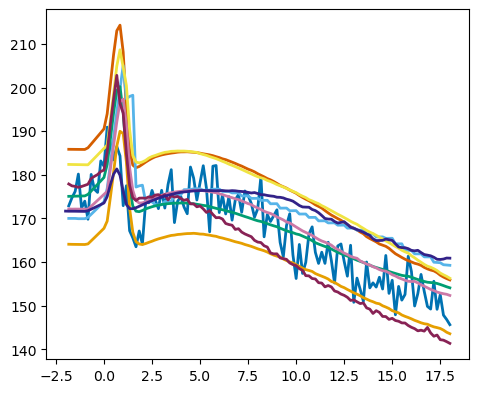

In [66]:
with_lines = True
skip = 2
ec = 'none'
FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM']
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288"]
rs_time = '3600S' # 30m
#######################################


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.figure(figsize=(12,10))
plt.subplot(2,2,1)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD CERES
error_1 = np.abs(ceres_dat_avg['lwflx'] - ceres_dat_avg['lwflx.25'])
error_2 = np.abs(ceres_dat_avg['lwflx.75'] - ceres_dat_avg['lwflx'])
error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1[1:],error_2[1:]]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(ceres_dat_avg.time[1:]/3600,ceres_dat_avg['lwflx'][1:],yerr=error_b,label='CERES',c='magenta',fmt='s')

plt.xlim(-2.5,18.5)
plt.ylim(140,230)
#plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'TOA $\uparrow$ LW Flux [W m$^{-2}$]',fontsize=18)
plt.title('Liquid Only',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.subplot(2,2,2)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD CERES
error_1 = np.abs(ceres_dat_avg['lwflx'] - ceres_dat_avg['lwflx.25'])
error_2 = np.abs(ceres_dat_avg['lwflx.75'] - ceres_dat_avg['lwflx'])
error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
error_b = [error_1[1:],error_2[1:]]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(ceres_dat_avg.time[1:]/3600,ceres_dat_avg['lwflx'][1:],yerr=error_b,label='CERES',c='magenta',fmt='s')

plt.xlim(-2.5,18.5)
plt.ylim(140,230)
#plt.xlabel(r'Time [h]',fontsize=18)
#plt.ylabel(r'TOA $\uparrow$ LW Flux [W m$^{-2}$]',fontsize=18)
plt.title('Mixed-Phase',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
#plt.legend(ncol=1,bbox_to_anchor=(1.01, 0.4), loc='upper left')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.subplot(2,2,3)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

plt.xlim(-2.5,18.5)
plt.ylim(115,300)
plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Sfc. $\downarrow$ LW Flux [W m$^{-2}$]',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.subplot(2,2,4)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3: # ignore mimica
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

plt.xlim(-2.5,18.5)
plt.ylim(115,300)
plt.xlabel(r'Time [h]',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)

plt.savefig('./paper/lwrad_ts_gewex.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()

## Plot LW time series (normalized by upwind, clearsky value) [Fig. 10]

In [143]:
modis_sub = modis_dat_avg[(~np.isnan(modis_dat_avg['cc']))]
viirs_sub = viirs_dat_avg[(~np.isnan(viirs_dat_avg['cc']))]

with_lines = True
skip = 2
ec = 'none'
FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM','SCALE']
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','CCPP','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288",'grey']
rs_time = '3600S' # 30m
#######################################


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.figure(figsize=(12,12))
axx=plt.subplot(3,2,1)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])
        
plt.xlim(-2.5,18.5)
plt.ylim(0.75,1.3)
#plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Norm. TOA $\uparrow$ LW Flux'+'\n'+'[-]',fontsize=18)
plt.title('Liquid Only',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[0], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(3,2,2)
yvar = 'rlut'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3:
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

plt.xlim(-2.5,18.5)
plt.ylim(0.75,1.3)
#plt.xlabel(r'Time [h]',fontsize=18)
#plt.ylabel(r'TOA $\uparrow$ LW Flux [W m$^{-2}$]',fontsize=18)
plt.title('Mixed-Phase',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
#plt.legend(ncol=1,bbox_to_anchor=(1.01, 0.15), loc='upper left')
axx.annotate(plot_label[1], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(3,2,3)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

plt.xlim(-2.5,18.5)
plt.ylim(0.9,2.4)
#plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Norm. Sfc. $\downarrow$ LW Flux'+'\n'+'[-]',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[2], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(3,2,4)
yvar = 'rlds'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3:
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now[yvar]/df_now_clear[yvar].values[0],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

plt.xlim(-2.5,18.5)
plt.ylim(0.9,2.4)
#plt.xlabel(r'Time [h]',fontsize=18)
#plt.legend(ncol=1,bbox_to_anchor=(1.01, 1.05), loc='upper left')
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[3], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(3,2,5)
iwp_thresh = 0.

## LES
xvar = 'cth'
yvar = 'clt'
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]

    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])
    
## SCM
yvar = 'cf'
for i in np.arange(len(unique_values_scm_noice)):
    df_now = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    df_now_clear = df_now[df_now['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD MODIS
error_1 = np.abs(modis_sub['clt'] - modis_sub['clt.25'])
error_2 = np.abs(modis_sub['clt.75'] - modis_sub['clt'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
#error_b = [error_1[0:],error_2[0:]]
error_b = [error_1,error_2]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(modis_sub.time/3600,modis_sub['clt'],yerr=error_b,label='MODIS',c='magenta',fmt='s')

error_1 = np.abs(viirs_sub['clt'] - viirs_sub['clt.25'])
error_2 = np.abs(viirs_sub['clt.75'] - viirs_sub['clt'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
#error_b = [error_1[0:],error_2[0:]]
error_b = [error_1,error_2]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(viirs_sub.time/3600,viirs_sub['clt'],yerr=error_b,label='VIIRS',c='magenta',fmt='p')

plt.xlim(-2.5,18.5)
plt.ylim(0.0,1.0)
plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Cloud Cover'+'\n'+'[-]',fontsize=18)
#plt.legend(ncol=1,bbox_to_anchor=(1.01, 1.05), loc='upper left')
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[4], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(3,2,6)

## earlier and more intense MBL stratification
iwp_thresh = 0.
xvar = 'cth'
yvar = 'clt'

## LES
for i in np.arange(len(unique_values_les)):
    #if i != 3:
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]

    plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])

## SCM
yvar = 'cf'
for i in np.arange(len(unique_values_scm)):
    df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
    df_now = df_now[df_now['time']<=64800.]
    
    if np.max(df_now[yvar]) > 1.:
        df_now[yvar] = df_now[yvar]/100.
        
    if i == 3:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

# ADD MODIS
error_1 = np.abs(modis_sub['clt'] - modis_sub['clt.25'])
error_2 = np.abs(modis_sub['clt.75'] - modis_sub['clt'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
#error_b = [error_1[0:],error_2[0:]]
error_b = [error_1,error_2]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(modis_sub.time/3600,modis_sub['clt'],yerr=error_b,label='MODIS',c='magenta',fmt='s')

error_1 = np.abs(viirs_sub['clt'] - viirs_sub['clt.25'])
error_2 = np.abs(viirs_sub['clt.75'] - viirs_sub['clt'])
#error_a = np.swapaxes([[error_1[0],error_2[0]]],0,1)
#error_b = [error_1[0:],error_2[0:]]
error_b = [error_1,error_2]
#plt.errorbar(ceres_dat_avg.time[0]/3600,ceres_dat_avg['lwflx'][0],yerr=error_a,c='grey',fmt='s')
plt.errorbar(viirs_sub.time/3600,viirs_sub['clt'],yerr=error_b,label='VIIRS',c='magenta',fmt='p')

plt.xlim(-2.5,18.5)
plt.ylim(0.0,1.0)
plt.xlabel(r'Time [h]',fontsize=18)
plt.legend(ncol=1,bbox_to_anchor=(1.25, 0.9), loc=8)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[5], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=12, fontweight='bold')

plt.savefig('./paper/norm_lwrad_ts_R1.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()

## Plot LW ratio time series [Fig. 11]

In [142]:
with_lines = True
skip = 2
ec = 'none'
FixN_labs = ['DALES','DHARMA','ICON','MIMICA','WRF','SAM','CM1','UCLALES-SALSA','MSU RCC DM','SCALE']
scm_labs = ['DALES-EDMFn','ModelE3','ICON-SCM','AOSCM','E3SM','SLAV','CCPP','LMDZ']
# Define a list of colorblind-friendly colors
cc = ["#0072B2", "#D55E00", "#56B4E9", "#009E73", "#F0E442", "#CC79A7", "#E69F00", "#882255", "#332288",'grey']
rs_time = '3600S' # 30m
#######################################


#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

plt.figure(figsize=(12,10))
axx=plt.subplot(2,1,1)
yvar = 'rlut'
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    df_now_noice = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear_noice = df_now_noice[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])

## SCM
for i in np.arange(len(unique_values_scm_noice)):
    if i == 3:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i+1]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    elif i == 4:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i+3]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    else:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    df_now_noice = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now_noice = df_now_noice[df_now_noice['time']<=64800.]
    df_now_clear_noice = df_now_noice[df_now_noice['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])        
    else:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

#plt.ylim(140,230)
plt.xticks(np.arange(-2.5,20,2.5))
#plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'TOA $\uparrow$ LW Flux Ratio [-]',fontsize=18)
plt.title('Ice Microphysics Impact on LW Fluxes',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)

plt.legend(ncol=1,bbox_to_anchor=(1.01, 0.3), loc='upper left')
axx.annotate(plot_label[0], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=20, fontweight='bold')

#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################
#####################################################################################################################################################################

axx=plt.subplot(2,1,2)
yvar = 'rlds'
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

## LES
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_all[df_col_1d_all['class']==unique_values_les[i]]
    df_now_clear = df_now[df_now['time']==-3600.]
    df_now_noice = df_col_1d_noice_all[df_col_1d_noice_all['class']==unique_values_les_noice[i]]
    df_now_clear_noice = df_now_noice[df_now['time']==-3600.]
    plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i],lw=2.,zorder=1,label=FixN_labs[i])

## SCM
for i in np.arange(len(unique_values_scm_noice)):
    if i == 3:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i+1]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    elif i == 4:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i+3]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    else:
        df_now = df_col_1d_scm_all[df_col_1d_scm_all['class']==unique_values_scm[i]]
        df_now = df_now[df_now['time']<=64800.]
        df_now_clear = df_now[df_now['time']==-3600.]
    df_now_noice = df_col_1d_scm_noice_all[df_col_1d_scm_noice_all['class']==unique_values_scm_noice[i]]
    df_now_noice = df_now_noice[df_now_noice['time']<=64800.]
    df_now_clear_noice = df_now_noice[df_now_noice['time']==-3600.]
    if i == 3:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i+1],lw=2.,ls='--',zorder=1,label=scm_labs[i+1])
    elif i == 4:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i+3],lw=2.,ls='--',zorder=1,label=scm_labs[i+3])
    else:
        plt.plot(df_now.time/3600.,df_now_noice[yvar]/df_now[yvar],c=cc[i],lw=2.,ls='--',zorder=1,label=scm_labs[i])

#plt.ylim(140,230)
plt.xticks(np.arange(-2.5,20,2.5))
plt.xlabel(r'Time [h]',fontsize=18)
plt.ylabel(r'Sfc. $\downarrow$ LW Flux Ratio [-]',fontsize=18)
#plt.title('Liquid Only',fontsize=18)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
axx.annotate(plot_label[1], xy=(0.025, 0.925), xycoords='axes fraction', fontsize=20, fontweight='bold')

plt.savefig('./paper/lwrad_ratio_ts_R1.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()

## Make panel scatter plots of LW flux ratio versus COD & cloud cover ratios [Fig. 12]
### Plot a single point for each model run, which is the average over the final 2h of simulation time
### Note we can only plot models that have both No Ice and FixN results available

In [183]:

plt.figure(figsize=(10,5))
yvar = 'rlut'
rs_time = '7200S' # 120m

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import linregress

## LES
od_arr = np.empty(len(unique_values_les_noice))
clt_arr = np.empty(len(unique_values_les_noice))
cth_arr = np.empty(len(unique_values_les_noice))
rlut_arr = np.empty(len(unique_values_les_noice))
rlds_arr = np.empty(len(unique_values_les_noice))
count = 0
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_all_cp[df_col_1d_all_cp['class']==unique_values_les[i]]
    df_now_rs = df_now.resample(rs_time).mean()
    df_now_noice = df_col_1d_noice_all_cp[df_col_1d_noice_all_cp['class']==unique_values_les_noice[i]]
    df_now_noice_rs = df_now_noice.resample(rs_time).mean()

    ## print values to check for (b) and (d)
    print(FixN_labs[i])
    if i==9:
        print(df_now_noice_rs['od'].values)
        #print(df_now_rs['od'].values)
        #print(df_now_noice_rs['rlut'].values[-1])
        #print(df_now_rs['rlut'].values[-1])
    
    if np.isnan(df_now_noice_rs['od'].values[-1]):
        print('OD == NaN in' + FixN_labs[i])
        df_now_noice_rs['od'].values[-1] = df_now_noice_rs['odlc'].values[-1].copy()
        print(df_now_noice_rs['od'].values[-1])
    
    axx=plt.subplot(2,3,3)
    # taking the value of the last index of each array represents the final 2h average
    plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[2], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    axx=plt.subplot(2,3,2)
    # taking the value of the last index of each array represents the final 2h average
    plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[1], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    axx=plt.subplot(2,3,1)
    plt.scatter(df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1],
                df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[0], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    axx=plt.subplot(2,3,6)
    plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[5], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    axx=plt.subplot(2,3,5)
    plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[4], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    axx=plt.subplot(2,3,4)
    plt.scatter(df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1],
                df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])
    axx.annotate(plot_label[3], xy=(0.06, 0.90), xycoords='axes fraction', fontsize=12, fontweight='bold')

    od_arr[count] = df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1]
    clt_arr[count] = df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1]
    cth_arr[count] = df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1]
    rlut_arr[count] = df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1]
    rlds_arr[count] = df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1]

    count+=1
        
####### COMPUTE R2 for LES only
mask = ~np.isnan(od_arr) 

# cth vs. upwelling LW
slope, intercept, r_value, p_value, std_err = linregress(cth_arr, rlut_arr)
r_squared_rlut_cth = r_value**2
print(f"R-squared for rlut and cth: {r_squared_rlut_cth:.4f}")

# cloud cover vs. upwelling LW
slope, intercept, r_value, p_value, std_err = linregress(clt_arr, rlut_arr)
r_squared_rlut_clt = r_value**2
print(f"R-squared for rlut and clt: {r_squared_rlut_clt:.4f}")

# COD vs. upwelling LW
slope, intercept, r_value, p_value, std_err = linregress(od_arr[mask], rlut_arr[mask])
r_squared_rlut_od = r_value**2
print(f"R-squared for rlut and od: {r_squared_rlut_od:.4f}")

# cth vs. downwelling LW
slope, intercept, r_value, p_value, std_err = linregress(cth_arr, rlds_arr)
r_squared_rlds_cth = r_value**2
print(f"R-squared for rlds and cth: {r_squared_rlds_cth:.4f}")

# cloud cover vs. downwelling LW
slope, intercept, r_value, p_value, std_err = linregress(clt_arr, rlds_arr)
r_squared_rlds_clt = r_value**2
print(f"R-squared for rlds and clt: {r_squared_rlds_clt:.4f}")

# COD vs. downwelling LW
slope, intercept, r_value, p_value, std_err = linregress(od_arr[mask], rlds_arr[mask])
r_squared_rlds_od = r_value**2
print(f"R-squared for rlds and od: {r_squared_rlds_od:.4f}")

## SCM
for i in np.arange(len(unique_values_scm_noice)):
    if i == 3: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        df_now = df_col_1d_scm_all_cp[df_col_1d_scm_all_cp['class']==unique_values_scm[i+1]]
    elif i == 4: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        df_now = df_col_1d_scm_all_cp[df_col_1d_scm_all_cp['class']==unique_values_scm[i+3]]
    else:
        df_now = df_col_1d_scm_all_cp[df_col_1d_scm_all_cp['class']==unique_values_scm[i]]
    df_now_rs = df_now.resample(rs_time).mean()
    df_now_noice = df_col_1d_scm_noice_all_cp[df_col_1d_scm_noice_all_cp['class']==unique_values_scm_noice[i]]
    df_now_noice_rs = df_now_noice.resample(rs_time).mean()
    
    if np.isnan(df_now_noice_rs['od'].values[-1]):
        print('OD == NaN in' + FixN_labs[i])
        #df_now_noice_rs['od'].values[-1] = df_now_noice_rs['odlc'].values[-1].copy()
        #print(df_now_noice_rs['odlc'].values[-1])
    
    if i == 3: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        plt.subplot(2,3,3)
        # taking the value of the last index of each array represents the final 2h average
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,3,2)
        # taking the value of the last index of each array represents the final 2h average
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.legend(ncol=1,bbox_to_anchor=(1.3, 0.7), loc=8)
        
        plt.subplot(2,3,1)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,3,6)
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,3,5)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,3,4)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])
    elif i == 4: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        plt.subplot(2,3,3)
        # taking the value of the last index of each array represents the final 2h average
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])

        plt.subplot(2,3,2)
        # taking the value of the last index of each array represents the final 2h average
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+3],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])

        plt.legend(ncol=1,bbox_to_anchor=(2.7, -1.0), loc=8)
        
        plt.subplot(2,3,1)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+3],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])

        plt.subplot(2,3,6)
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])

        plt.subplot(2,3,5)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+3],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])

        plt.subplot(2,3,4)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+3],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+3])
    else:
        plt.subplot(2,3,3)
        # taking the value of the last index of each array represents the final 2h average
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,3,2)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,3,1)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,3,6)
        plt.scatter(df_now_noice_rs['cth'].values[-1]/df_now_rs['cth'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,3,5)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,3,4)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

plt.subplot(2,3,3)
plt.ylim(0.65,1.05)
#plt.ylabel(r'TOA $\uparrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(0.95,0.71,'r$^{2}$='+str(np.round(r_squared_rlut_cth,2)))
        
plt.subplot(2,3,2)
plt.ylim(0.65,1.05)
#plt.ylabel(r'TOA $\uparrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.5,0.71,'r$^{2}$='+str(np.round(r_squared_rlut_od,2)))

plt.subplot(2,3,1)
plt.ylim(0.65,1.05)
plt.ylabel(r'TOA $\uparrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.08,0.71,'r$^{2}$='+str(np.round(r_squared_rlut_clt,2)))

plt.subplot(2,3,6)
plt.ylim(0.95,1.2)
plt.xlabel('Cloud-Top Height Ratio [-]',fontsize=12)
#plt.ylabel(r'Sfc. $\downarrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(0.95,1.106,'r$^{2}$='+str(np.round(r_squared_rlds_cth,2)))

plt.subplot(2,3,5)
plt.ylim(0.95,1.2)
plt.xlabel('Optical Depth Ratio [-]',fontsize=12)
#plt.ylabel(r'Sfc. $\downarrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.5,1.106,'r$^{2}$='+str(np.round(r_squared_rlds_od,2)))

plt.subplot(2,3,4)
plt.ylim(0.95,1.20)
plt.xlabel('Cloud Cover Ratio [-]',fontsize=12)
plt.ylabel(r'Sfc. $\downarrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.08,1.106,'r$^{2}$='+str(np.round(r_squared_rlds_clt,2)))


plt.savefig('./paper/lwrad_cld_scatter_R1.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()

DALES
DHARMA
ICON
MIMICA
WRF
SAM
CM1
UCLALES-SALSA
MSU RCC DM
SCALE
[nan nan nan nan nan nan nan nan nan nan]
OD == NaN inSCALE
24.767500082651775
R-squared for rlut and cth: 0.5707
R-squared for rlut and clt: 0.5008
R-squared for rlut and od: 0.5096
R-squared for rlds and cth: 0.4377
R-squared for rlds and clt: 0.6030
R-squared for rlds and od: 0.6210
OD == NaN inDALES
OD == NaN inICON
OD == NaN inMIMICA


## Same as Fig. 12 above, except for GEWEX Quarterly

In [ ]:
plt.figure(figsize=(6,5))
yvar = 'rlut'
rs_time = '7200S' # 120m

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import linregress

## LES
od_arr = np.empty(len(unique_values_les_noice))
clt_arr = np.empty(len(unique_values_les_noice))
rlut_arr = np.empty(len(unique_values_les_noice))
rlds_arr = np.empty(len(unique_values_les_noice))
count = 0
for i in np.arange(len(unique_values_les_noice)):
    #if i != 3:
    df_now = df_col_1d_all_cp[df_col_1d_all_cp['class']==unique_values_les[i]]
    df_now_rs = df_now.resample(rs_time).mean()
    df_now_noice = df_col_1d_noice_all_cp[df_col_1d_noice_all_cp['class']==unique_values_les_noice[i]]
    df_now_noice_rs = df_now_noice.resample(rs_time).mean()

    plt.subplot(2,2,2)
    plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])

    plt.subplot(2,2,1)
    plt.scatter(df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1],
                df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])

    plt.subplot(2,2,4)
    plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])

    plt.subplot(2,2,3)
    plt.scatter(df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1],
                df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],edgecolor='k',zorder=1,label=FixN_labs[i])

    od_arr[count] = df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1]
    clt_arr[count] = df_now_noice_rs['clt'].values[-1]/df_now_rs['clt'].values[-1]
    rlut_arr[count] = df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1]
    rlds_arr[count] = df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1]

    count+=1
        
####### COMPUTE R2 for LES only
# cloud cover vs. upwelling LW
slope, intercept, r_value, p_value, std_err = linregress(clt_arr, rlut_arr)
r_squared_rlut_clt = r_value**2
print(f"R-squared for rlut and clt: {r_squared_rlut_clt:.4f}")

# COD vs. upwelling LW
slope, intercept, r_value, p_value, std_err = linregress(od_arr, rlut_arr)
r_squared_rlut_od = r_value**2
print(f"R-squared for rlut and od: {r_squared_rlut_od:.4f}")

# cloud cover vs. downwelling LW
slope, intercept, r_value, p_value, std_err = linregress(clt_arr, rlds_arr)
r_squared_rlds_clt = r_value**2
print(f"R-squared for rlds and clt: {r_squared_rlds_clt:.4f}")

# COD vs. downwelling LW
slope, intercept, r_value, p_value, std_err = linregress(od_arr, rlds_arr)
r_squared_rlds_od = r_value**2
print(f"R-squared for rlds and od: {r_squared_rlds_od:.4f}")
        
    
## SCM
for i in np.arange(len(unique_values_scm_noice)):
    if i == 3: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        df_now = df_col_1d_scm_all_cp[df_col_1d_scm_all_cp['class']==unique_values_scm[i+1]]
    else:
        df_now = df_col_1d_scm_all_cp[df_col_1d_scm_all_cp['class']==unique_values_scm[i]]
    df_now_rs = df_now.resample(rs_time).mean()
    df_now_noice = df_col_1d_scm_noice_all_cp[df_col_1d_scm_noice_all_cp['class']==unique_values_scm_noice[i]]
    df_now_noice_rs = df_now_noice.resample(rs_time).mean()
    
    if i == 3: # skipping AOSCM to get to E3SM, since AOSCM does not have No Ice results
        plt.subplot(2,2,2)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        #plt.legend(ncol=1,bbox_to_anchor=(1.01, 0.7), loc='upper left')
        
        plt.subplot(2,2,1)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,2,4)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])

        plt.subplot(2,2,3)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i+1],marker='s',edgecolor='k',zorder=1,label=scm_labs[i+1])
    else:
        plt.subplot(2,2,2)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,2,1)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlut'].values[-1]/df_now_rs['rlut'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,2,4)
        plt.scatter(df_now_noice_rs['od'].values[-1]/df_now_rs['od'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])

        plt.subplot(2,2,3)
        plt.scatter(df_now_noice_rs['cf'].values[-1]/df_now_rs['cf'].values[-1],
                    df_now_noice_rs['rlds'].values[-1]/df_now_rs['rlds'].values[-1],facecolor=cc[i],marker='s',edgecolor='k',zorder=1,label=scm_labs[i])
        
plt.subplot(2,2,2)
plt.ylim(0.65,1.05)
#plt.ylabel(r'TOA $\uparrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(9,1.0,'r$^{2}$='+str(np.round(r_squared_rlut_od,2)))

plt.subplot(2,2,1)
plt.ylim(0.65,1.05)
plt.ylabel(r'TOA $\uparrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(2.7,1.0,'r$^{2}$='+str(np.round(r_squared_rlut_clt,2)))

plt.subplot(2,2,4)
plt.xlabel('Optical Depth Ratio [-]',fontsize=12)
#plt.ylabel(r'Sfc. $\downarrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.0,1.25,'r$^{2}$='+str(np.round(r_squared_rlds_od,2)))

plt.subplot(2,2,3)
plt.xlabel('Cloud Cover Ratio [-]',fontsize=12)
plt.ylabel(r'Sfc. $\downarrow$'+'LW\nFlux Ratio [-]',fontsize=12)
ax=plt.gca()
ax.grid(zorder=0)
ax.set_axisbelow(True)
plt.text(1.0,1.25,'r$^{2}$='+str(np.round(r_squared_rlds_clt,2)))


plt.savefig('./paper/lwrad_cld_scatter_gewex.png',dpi=600,bbox_inches='tight')    
plt.close()
#plt.show()